In [1]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

env = gym.make("CartPole-v1", render_mode="rgb_array")

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
import warnings
warnings.filterwarnings("ignore")

In [2]:
torch.__version__

'2.5.1+cpu'

In [3]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))
class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [4]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

In [ ]:
BATCH_SIZE = 128 # is the number of transitions sampled from the replay buffer
GAMMA = 0.99 # the discount factor as mentioned in the previous section
eps_init = 0.9 # the starting value of epsilon
eps_min = 0.05 # the final value of epsilon
eps_decay = 1000 # controls the rate of exponential decay of epsilon, higher means a slower decay
# tau = 0.005
tau = 0.005 # the update rate of the target network

alpha = 1e-4 # the learning rate of the ``AdamW`` optimizer

n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=alpha, amsgrad=True)
memory = ReplayMemory(10000)

In [ ]:



steps_done = 0


def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = eps_min + (eps_init - eps_min) * math.exp(-1. * steps_done / eps_decay)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)


episode_durations = []


def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [ ]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)

    batch = Transition(*zip(*transitions))
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)


    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

In [8]:
import imageio
import numpy as np
num_runs = 4
num_episodes = 700

all_images_DQN = []
all_durations_DQN = []
gif_episode_numbers = [1, 100, 400, 500, num_episodes-1]
for i_runs in range(num_runs):
    all_images_DQN = []

    durations = []
    BATCH_SIZE = 128
    GAMMA = 0.99
    eps_init = 0.9
    # eps_init = 1
    
    eps_min = 0.05
    #eps_min = 0.1
    eps_decay = 1000
    # tau = 0.005
    tau = 0.005
    alpha = 1e-4

    state, info = env.reset()
        
    policy_net = DQN(n_observations, n_actions).to(device)
    target_net = DQN(n_observations, n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    
    optimizer = optim.AdamW(policy_net.parameters(), lr=alpha, amsgrad=True)
    memory = ReplayMemory(10000)
    
    
    steps_done = 0
    images = []
    all_images = []
    for i_episode in range(num_episodes):
        # print(i_episode)
        images = []
        state, info = env.reset()
        state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        for t in count():
            if i_episode in gif_episode_numbers:
                env.render()
                img = env.render()
                images.append(img)
            action = select_action(state)
            observation, reward, terminated, truncated, _ = env.step(action.item())
            reward = torch.tensor([reward], device=device)
            done = terminated or truncated
    
            if terminated:
                next_state = None
            else:
                next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
    
            memory.push(state, action, next_state, reward)
            state = next_state
            
            optimize_model()
            
            target_net_state_dict = target_net.state_dict()
            policy_net_state_dict = policy_net.state_dict()
            for key in policy_net_state_dict:
                target_net_state_dict[key] = policy_net_state_dict[key]*tau + target_net_state_dict[key]*(1-tau)
            target_net.load_state_dict(target_net_state_dict)
    
            if done:
                episode_durations.append(t + 1)
                durations.append(t + 1)
                break
        if i_episode in gif_episode_numbers:
            all_images_DQN.append(images)
    all_durations_DQN.append(durations)
    print('Run complete')

        
print('All Complete')
plt.ioff()
plt.show()

Run complete
Run complete
Run complete
Run complete
All Complete


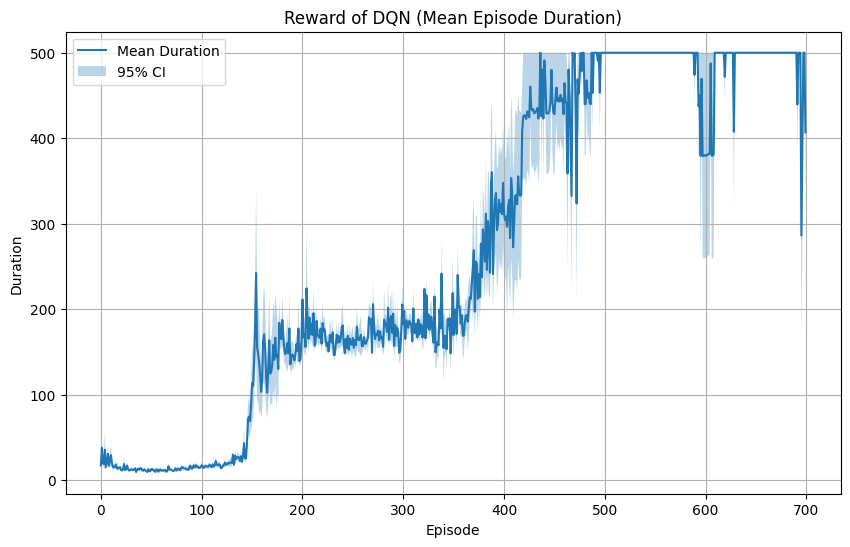

In [ ]:
from scipy.stats import sem
all_durations = np.array(all_durations_DQN)

mean_durations = np.mean(all_durations, axis=0)
confidence_intervals = sem(all_durations, axis=0)  # Standard error of mean

# Plotting
plt.figure(figsize=(10, 6))
x = np.arange(all_durations.shape[1])
plt.plot(x, mean_durations, label="Mean Duration")
plt.fill_between(x, mean_durations - confidence_intervals, mean_durations + confidence_intervals, alpha=0.3, label="95% CI")
plt.xlabel("Episode")
plt.ylabel("Duration")
plt.title("Reward of DQN (Mean Episode Duration)")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Visualize
for i in [1, 2, 3, 4, 5]:
    images = all_images_DQN[i-1]
    output_filename = f'cartpole_DQN{i}.mp4'
    imageio.mimsave(output_filename, [np.array(img) for img in images], fps=30)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input ima

## Dueling DQN

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DuelingDQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DuelingDQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.value_layer = nn.Linear(128, 1)  # Outputs a single value, V(s)
        self.advantage_layer = nn.Linear(128, n_actions)  # Outputs advantages, A(s, a)
    
    def forward(self, x):
        # Shared network
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        value = self.value_layer(x)
        advantage = self.advantage_layer(x)
        # Combine to calculate Q-values
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q_values


In [ ]:

BATCH_SIZE = 128
GAMMA = 0.99
eps_init = 0.9
eps_min = 0.05
eps_decay = 1000
# tau = 0.005
tau = 0.005

alpha = 1e-4

n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

policy_net = DuelingDQN(n_observations, n_actions).to(device)
target_net = DuelingDQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=alpha, amsgrad=True)
memory = ReplayMemory(10000)


steps_done = 0


def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = eps_min + (eps_init - eps_min) * math.exp(-1. * steps_done / eps_decay)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)


episode_durations = []


def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [ ]:
import imageio
import numpy as np
num_runs = 2
num_episodes = 700

all_images_DDQN = []
all_durations_DDQN = []
gif_episode_numbers = [1, 100, 400, num_episodes-1]
for i_runs in range(num_runs):
    all_images_DDQN = []
    durations = []
    BATCH_SIZE = 128
    GAMMA = 0.99
    eps_init = 0.9
    # eps_init = 1
    
    eps_min = 0.05
    #eps_min = 0.1
    eps_decay = 1000
    tau = 0.005
    alpha = 1e-4

    state, info = env.reset()
        
    policy_net = DuelingDQN(n_observations, n_actions).to(device)
    target_net = DuelingDQN(n_observations, n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    
    optimizer = optim.AdamW(policy_net.parameters(), lr=alpha, amsgrad=True)
    memory = ReplayMemory(10000)
    
    
    steps_done = 0
    images = []
    all_images = []
    for i_episode in range(num_episodes):
        # print(i_episode)
        images = []
        state, info = env.reset()
        state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        for t in count():
            if i_episode in gif_episode_numbers:
                env.render()
                img = env.render()
                images.append(img)
            action = select_action(state)
            observation, reward, terminated, truncated, _ = env.step(action.item())
            reward = torch.tensor([reward], device=device)
            done = terminated or truncated
    
            if terminated:
                next_state = None
            else:
                next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
    
            memory.push(state, action, next_state, reward)
            state = next_state
            
            optimize_model()
            
            if i_episode % 1 == 0:
                target_net_state_dict = target_net.state_dict()
                policy_net_state_dict = policy_net.state_dict()
                for key in policy_net_state_dict:
                    target_net_state_dict[key] = policy_net_state_dict[key]*tau + target_net_state_dict[key]*(1-tau)
                target_net.load_state_dict(target_net_state_dict)
    
            if done:
                episode_durations.append(t + 1)
                durations.append(t + 1)
                break
        if i_episode in gif_episode_numbers:
            all_images_DDQN.append(images)
    all_durations_DDQN.append(durations)
        
print('Complete')
plt.ioff()
plt.show()

Complete


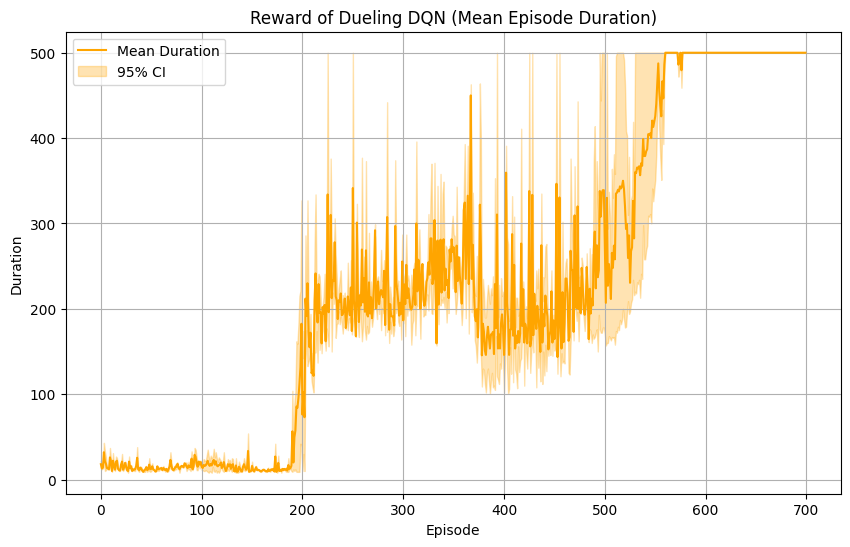

In [26]:
from scipy.stats import sem
all_durations = np.array(all_durations_DDQN)

mean_durations = np.mean(all_durations, axis=0)
confidence_intervals = sem(all_durations, axis=0)  # Standard error of mean

# Plotting
plt.figure(figsize=(10, 6))
x = np.arange(all_durations.shape[1])
plt.plot(x, mean_durations, label="Mean Duration", color='orange')
plt.fill_between(x, mean_durations - confidence_intervals, mean_durations + confidence_intervals, alpha=0.3, label="95% CI", color='orange')
plt.xlabel("Episode")
plt.ylabel("Duration")
plt.title("Reward of Dueling DQN (Mean Episode Duration)")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
len(all_images_DDQN)

8

In [41]:
# Visualize
for i in [1, 2, 3, 4]:
    images = all_images_DDQN[i-1]
    output_filename = f'cartpole_DDQN{i}.mp4'
    imageio.mimsave(output_filename, [np.array(img) for img in images], fps=30)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input ima

In [ ]:
def plot_durationss(all_durations_DDQN=None, all_durations_DQN=None):
    if all_durations_DDQN is None and all_durations_DQN is None:
        raise ValueError("At least one of all_durations_DDQN or all_durations_DQN must be provided.")

    plt.figure(figsize=(10, 6))
    
    if all_durations_DQN is not None:
        all_durations_DQN = np.array(all_durations_DQN)
        mean_durations_DQN = np.mean(all_durations_DQN, axis=0)
        confidence_intervals_DQN = sem(all_durations_DQN, axis=0)  # Standard error of mean
        x_DQN = np.arange(all_durations_DQN.shape[1])
        plt.plot(x_DQN, mean_durations_DQN, label="DQN duration")
        plt.fill_between(x_DQN, mean_durations_DQN - confidence_intervals_DQN, mean_durations_DQN + confidence_intervals_DQN, alpha=0.3)
    if all_durations_DDQN is not None:
        all_durations_DDQN = np.array(all_durations_DDQN)
        mean_durations_DDQN = np.mean(all_durations_DDQN, axis=0)
        confidence_intervals_DDQN = sem(all_durations_DDQN, axis=0)  # Standard error of mean
        x_DDQN = np.arange(all_durations_DDQN.shape[1])
        plt.plot(x_DDQN, mean_durations_DDQN, label="DDQN duration")
        plt.fill_between(x_DDQN, mean_durations_DDQN - confidence_intervals_DDQN, mean_durations_DDQN + confidence_intervals_DDQN, alpha=0.3)
    
    plt.xlabel("Episode")
    plt.ylabel("Duration")
    plt.title("Comparing DQN & Dueling DQN")
    plt.legend()
    plt.grid()
    plt.show()

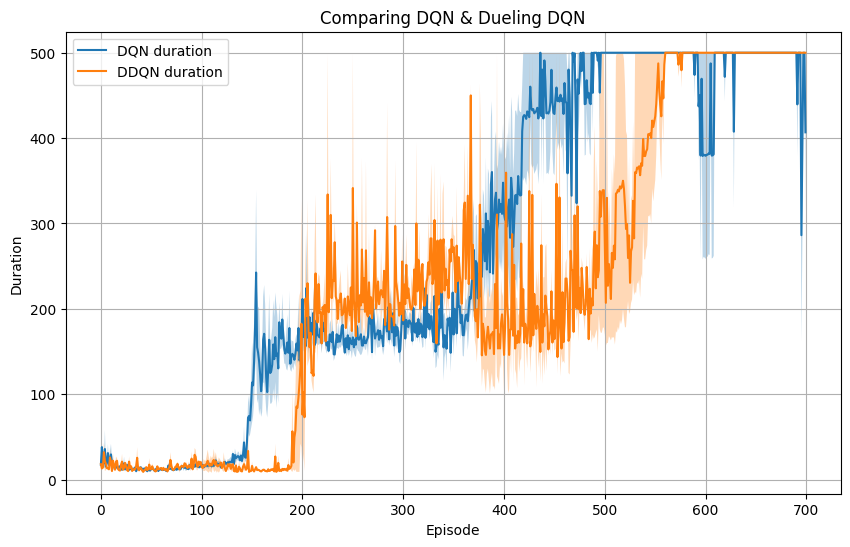

In [36]:
plot_durationss(all_durations_DDQN, all_durations_DQN)